# Скачиваем датасет с Kaggle, распаковываем архив

In [ ]:
# Install Kaggle package
!pip install kaggle >> None

# Download the Rock Paper Scissors dataset from Kaggle
!kaggle datasets download -d sanikamal/rock-paper-scissors-dataset

# Unzip the dataset
!unzip rock-paper-scissors-dataset.zip >> None

Dataset URL: https://www.kaggle.com/datasets/sanikamal/rock-paper-scissors-dataset
License(s): other
 98% 441M/452M [00:12<00:00, 28.9MB/s]
100% 452M/452M [00:12<00:00, 37.2MB/s]


# Приводим данные к нужному формату, добавляем аугментации

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import time
import os
import copy

from tqdm import tqdm

from torch.optim import lr_scheduler

# Define paths
data_dir = 'Rock-Paper-Scissors'

# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # приведение к одному размеру
        transforms.RandomHorizontalFlip(), # аугментация - отзеркаливание
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # нормализация по каналам
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'Rock-Paper-Scissors'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'test']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4) for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Running model on ', device)

Running model on  cuda:0


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Визуализируем датасет

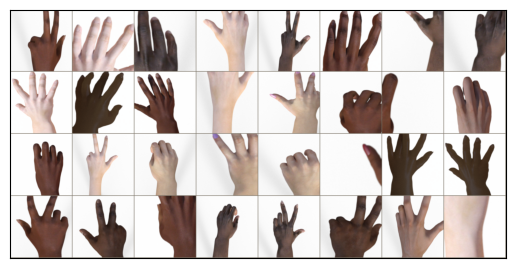

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Function to show images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.xticks([])  # Remove x-ticks
    plt.yticks([])  # Remove y-ticks
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Plot the images
imshow(out, title=[class_names[x] for x in classes])


# Прописываем общую функцию для обучения

In [ ]:
# [-8.1, 2.3, 0.9] -> paper
# 0 - rock
# 1 - paper
# 2 - scissors

In [ ]:
# Function to train the model
def train_model(model, criterion, optimizer, scheduler, num_epochs=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

# Задаем две модели - с нуля и предобученную. У предобученной замораживаем веса, запускаем их обучение

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import time
import os
import copy

from tqdm import tqdm

from torch.optim import lr_scheduler

model_ft_pretrained = models.resnet18(weights='IMAGENET1K_V1')

model_ft_pretrained

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 81.0MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model_ft_pretrained.fc = nn.Linear(512, 3)
model_ft_pretrained

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
x = torch.rand(1,3,256,256)
model_ft_pretrained(x)

tensor([[-1.7034, -0.3745, -0.5726]], grad_fn=<AddmmBackward0>)

In [ ]:
y = torch.nn.Softmax()(model_ft_pretrained(x))
print(y)

tensor([[0.1270, 0.4796, 0.3934]], grad_fn=<SoftmaxBackward0>)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1553: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [ ]:
y = torch.nn.Sigmoid()(model_ft_pretrained(x))
print(y)

tensor([[0.1540, 0.4074, 0.3606]], grad_fn=<SigmoidBackward0>)


In [ ]:
# Load ResNet-18 model trained from scratch
model_ft_scratch = models.resnet18(pretrained=False) # НЕ предобученная модель (pretrained=False)
num_ftrs = model_ft_scratch.fc.in_features
model_ft_scratch.fc = nn.Linear(num_ftrs, len(class_names)) # задаем 3 класса на выходе
model_ft_scratch = model_ft_scratch.to(device)

criterion = nn.CrossEntropyLoss() # Задаем функцию потерь

optimizer_ft_scratch = optim.SGD(model_ft_scratch.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler_scratch = lr_scheduler.StepLR(optimizer_ft_scratch, step_size=7, gamma=0.1)

# Запускаем обучение на 5 эпох
print("Training ResNet-18 from scratch")
model_ft_scratch = train_model(model_ft_scratch, criterion, optimizer_ft_scratch, exp_lr_scheduler_scratch, num_epochs=5)

# Задаем предобученную на ImageNet модель.
model_ft_pretrained = models.resnet18(weights='IMAGENET1K_V1')

# Замораживаем все слои модели
for param in model_ft_pretrained.parameters():
    param.requires_grad = False

num_ftrs = model_ft_pretrained.fc.in_features
model_ft_pretrained.fc = nn.Linear(num_ftrs, len(class_names)) # При перезаписи, новый слой будет "разморожен"
model_ft_pretrained = model_ft_pretrained.to(device) # Отправляем на GPU

# Указываем оптимизатору, что только последний слой надо обновлять
optimizer_ft_pretrained = optim.SGD(model_ft_pretrained.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler_pretrained = lr_scheduler.StepLR(optimizer_ft_pretrained, step_size=7, gamma=0.1)

# Запускаем обучение на 5 эпох
print("Fine-tuning pretrained ResNet-18")
model_ft_pretrained = train_model(model_ft_pretrained, criterion, optimizer_ft_pretrained, exp_lr_scheduler_pretrained, num_epochs=5)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Training ResNet-18 from scratch
Epoch 0/4
----------


100%|██████████| 79/79 [00:21<00:00,  3.64it/s]


train Loss: 1.0368 Acc: 0.4540


100%|██████████| 12/12 [00:02<00:00,  4.16it/s]


...

test Loss: 0.4473 Acc: 0.7823
Epoch 4/4
----------


100%|██████████| 79/79 [00:12<00:00,  6.29it/s]


train Loss: 0.3351 Acc: 0.8845


100%|██████████| 12/12 [00:02<00:00,  5.61it/s]

test Loss: 0.3296 Acc: 0.8683
Training complete in 1m 14s
Best val Acc: 0.8925


# Выводы

### Обучение с нуля:

Время: 1m23s

Best val Acc: 0.6559

### Дообучение:

Время: 1m16s

Best val Acc: 0.9274

In [ ]:
torch.save(model_ft_pretrained.state_dict(), 'resnet18_rock_paper_scissors_finetuned.pth')

In [1]:
# %pip install boto3 if needed
# set os environment variables aws_access_key_id and aws_secret_access_key

import os
import boto3


def upload_file(src_file: str, bucket: str, dist_directory: str) -> None:
    client.upload_file(src_file, bucket, os.path.join(dist_directory, os.path.basename(src_file)))


S3_CREDS = {
    "aws_access_key_id": os.environ["aws_access_key_id"],
    "aws_secret_access_key": os.environ["aws_secret_access_key"]
}

bucket = "my-bucket-zerocoder-llm"
dist_directory = ""
src_file = 'resnet18_rock_paper_scissors_finetuned.pth'

client = boto3.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net',
    **S3_CREDS)

upload_file(src_file, bucket, dist_directory)


In [2]:
bucket = "my-bucket-zerocoder-llm"
dist_directory = ""
src_file = 'rps-bot.py'

client = boto3.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net',
    **S3_CREDS)

upload_file(src_file, bucket, dist_directory)